# Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_csv(r"C:\Users\Public\My projects\notebook\Notebook\Students perfomance\stud.csv")
df = data.copy()
df.shape

(1000, 8)

In [3]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.tail(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [7]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [8]:
print("Unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Unique values in each column:
gender: ['female' 'male']
race_ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
parental_level_of_education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch: ['standard' 'free/reduced']
test_preparation_course: ['none' 'completed']
math_score: [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
reading_score: [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
writin

# Now replacing some values 

In [9]:
df['gender'] = df['gender'].replace({'male': 0, 'female': 1})

df.rename(
	columns={
		'parental_level_of_education': "parent's_education",
		'parental level of education': "parent's_education",
		'test_preparation_course': 'prep_course',
		'test preparation course': 'prep_course',
		'lunch': 'lunch_type',
	},
	inplace=True
)

df["parent's_education"] = df["parent's_education"].replace({
	'some high school': 0,
	'high school': 1,
	'some college': 2,
	"associate's degree": 3,
	"bachelor's degree": 4,
	"master's degree": 5
})
df["race_ethnicity"] = df["race_ethnicity"].replace({
	'group A': 0,
	'group B': 1,
	'group C': 2,
	'group D': 3,
	'group E': 4
})
df["prep_course"] = df["prep_course"].replace({'none': 0, 'completed': 1})
df["lunch_type"] = df["lunch_type"].replace({'standard': 0, 'free/reduced': 1})

In [10]:
df.head(4)

,gender,race_ethnicity,parent's_education,lunch_type,prep_course,math_score,reading_score,writing_score
0,1,1,4,0,0,72,72,74
1,1,2,2,0,1,69,90,88
2,1,1,5,0,0,90,95,93
3,0,0,3,1,0,47,57,44


# Now visualizing the correlation

In [11]:
def correlation_visualization(df):
    plt.figure(figsize=(20, 14))
    sns.heatmap(
        df.corr(),
        annot=True,
         cmap='coolwarm', 
        cbar=True, 
         annot_kws={"size": 17, "weight": "bold", "color": "black"},
        vmin=0,
        vmax=1
         )
    plt.title('Correlation Heatmap', fontsize=30, weight='bold')
    plt.xticks(rotation=45, fontsize=16)
    plt.yticks(rotation=0, fontsize=16)
    plt.tight_layout()
    plt.show()


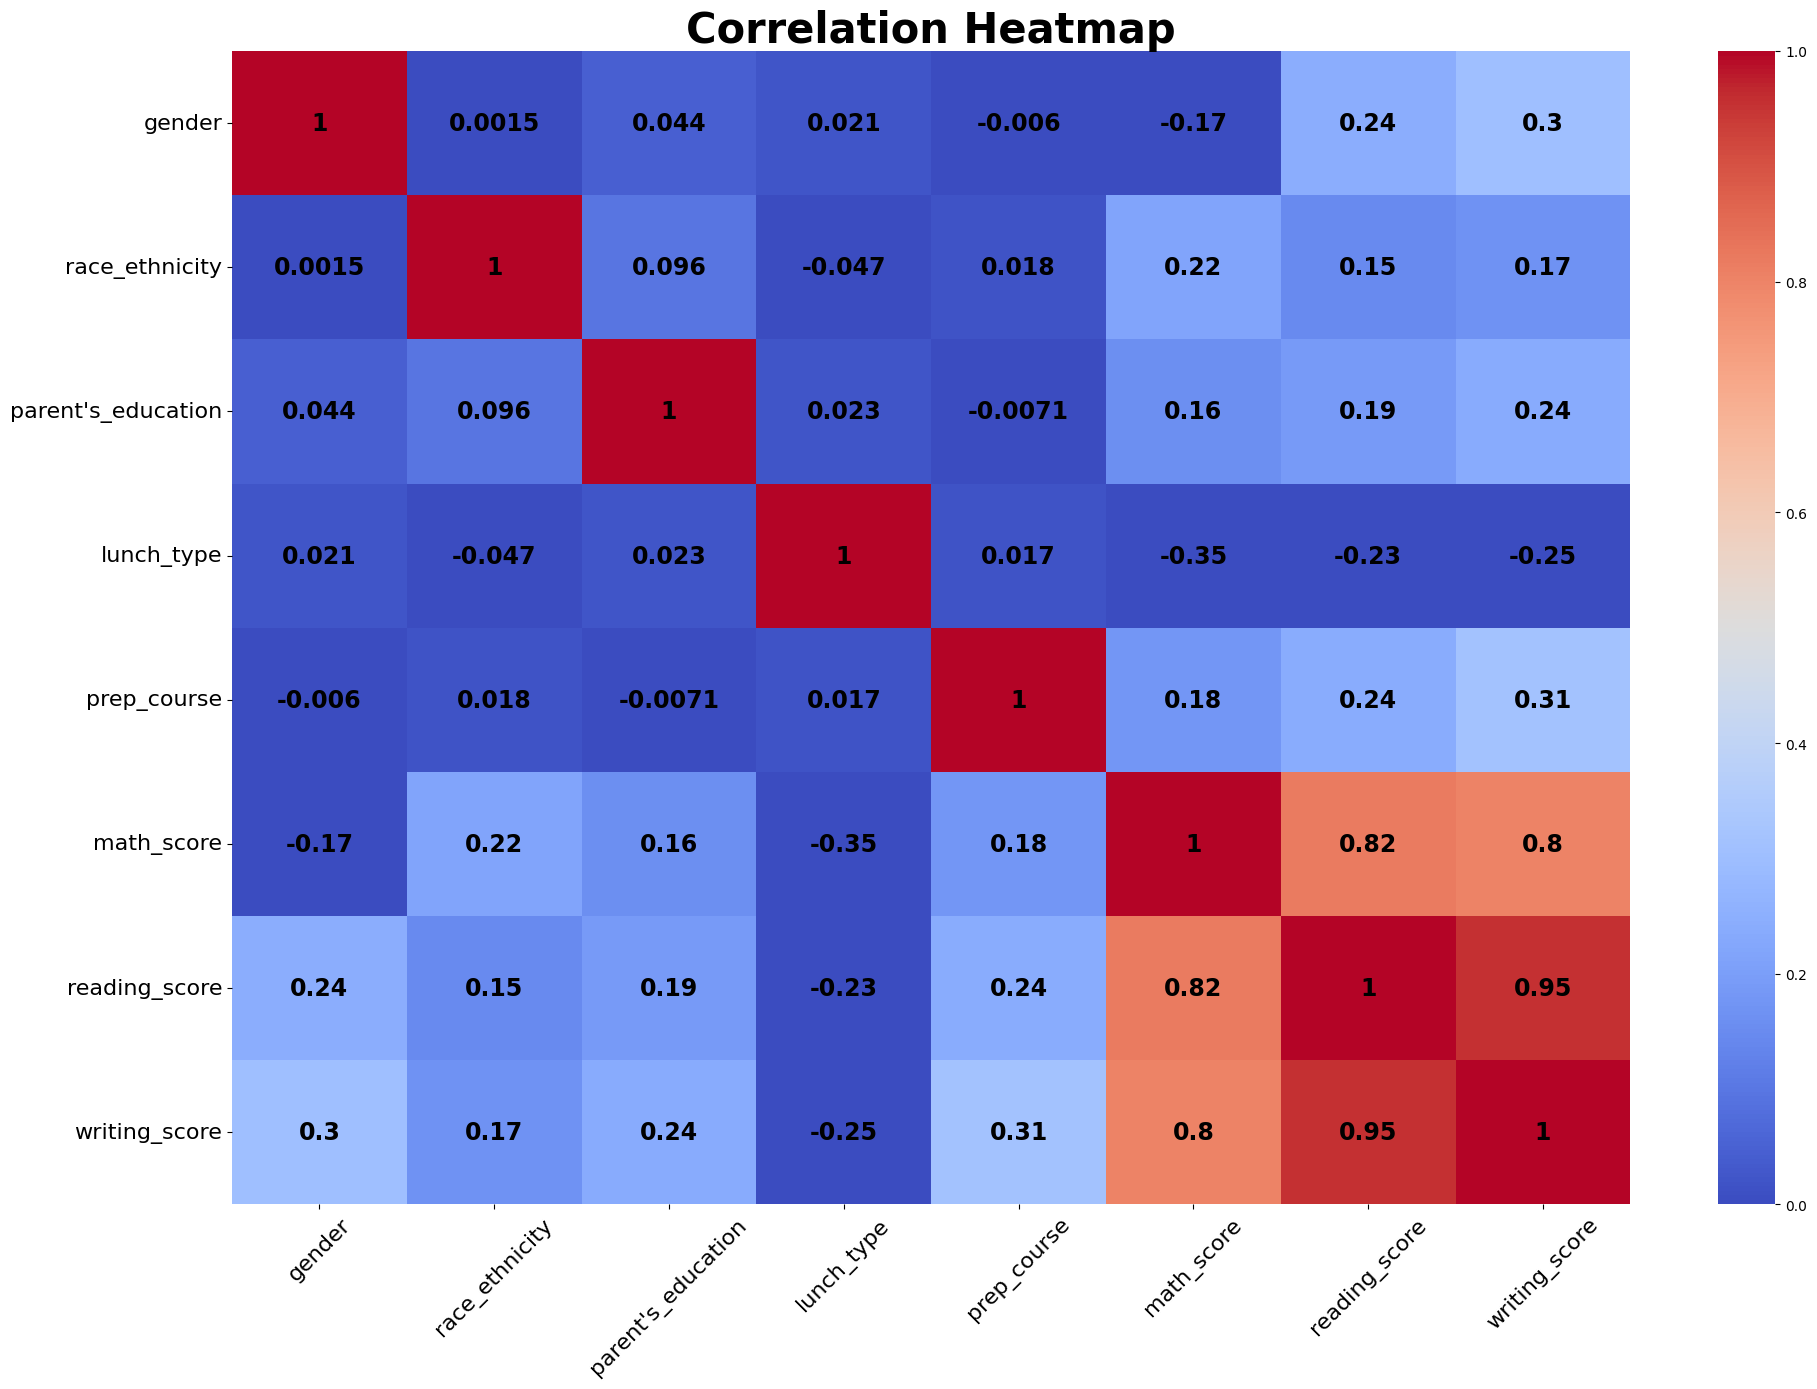

In [12]:
correlation_visualization(df)

# Saving the transformed data into csv file

In [13]:
'''
from pathlib import Path

output_path = Path(r"cleaned_students_performance.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)

'''

'\nfrom pathlib import Path\n\noutput_path = Path(r"cleaned_students_performance.csv")\noutput_path.parent.mkdir(parents=True, exist_ok=True)\n\ndf.to_csv(output_path, index=False)\n\n'

In [14]:
df.duplicated().sum()

0

In [15]:
df.describe()

,gender,race_ethnicity,parent's_education,lunch_type,prep_course,math_score,reading_score,writing_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.518000,2.174000,2.081000,0.355000,0.358000,66.08900,69.169000,68.054000
std,0.499926,1.157179,1.460333,0.478753,0.479652,15.16308,14.600192,15.195657
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,17.000000,10.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,57.00000,59.000000,57.750000
50%,1.000000,2.000000,2.000000,0.000000,0.000000,66.00000,70.000000,69.000000
75%,1.000000,3.000000,3.000000,1.000000,1.000000,77.00000,79.000000,79.000000
max,1.000000,4.000000,5.000000,1.000000,1.000000,100.00000,100.000000,100.000000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gender              1000 non-null   int64
 1   race_ethnicity      1000 non-null   int64
 2   parent's_education  1000 non-null   int64
 3   lunch_type          1000 non-null   int64
 4   prep_course         1000 non-null   int64
 5   math_score          1000 non-null   int64
 6   reading_score       1000 non-null   int64
 7   writing_score       1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB
